# Thesis - Vertrauen durch Validierung

**Eine quantitative Evaluation der Robustheit und Erklärungstreue von XAI-Methoden bei der dermatologischen Bildklassifikation auf dem HAM10000-Datensatz.**

Dieses Notebook demonstriert die gesamte experimentelle Pipeline der Bachelorarbeit: Vom Laden und Aufbereiten der dermatologischen Bilddaten über das Training der Convolutional Neural Networks (ResNet-101 und MobileNetV3) bis hin zur abschließenden quantitativen Evaluation der Explainable AI (XAI) Methoden LIME und Grad-CAM mithilfe des Quantus-Frameworks.

## 0. Installation
In diesem Schritt werden alle benötigten Bibliotheken und Abhängigkeiten installiert. Neben den Standard-Bibliotheken für Deep Learning (PyTorch) werden hier insbesondere captum für die Erklärungsgenerierung sowie quantus für die quantitative Validierung der XAI-Methoden benötigt

In [7]:
# Führe diese Zelle nur aus, wenn die Pakete noch nicht installiert sind.
# Das Flag -q sorgt dafür, dass der Output nicht das ganze Notebook überflutet.

# Tipp: Eine eigene Umgebung dafür erstellen. Im Anaconda Prompt folgende Befehle ausführen:
#  - conda create --name thesis_env python=3.11 -y
#  - conda activate ml_env
#  - conda install ipykernel -y
#  - python -m ipykernel install --user --name thesis_env --display-name "cb thesis env"

# 1. Alle großen "schweren" Pakete über Conda installieren. 
# Das ! erlaubt den Terminal-Befehl im Notebook und das -y bestätigt die Installation automatisch.
#!conda install -y -c pytorch -c nvidia -c conda-forge pytorch torchvision pytorch-cuda=12.4 pandas "numpy<2.0" seaborn matplotlib ipywidgets scikit-learn scikit-image imbalanced-learn captum

# 2. Nur spezielle Pakete (wie quantus), die es bei Conda oft nicht gibt, über pip installieren:
#%pip install quantus

In [132]:
# 1. Python Standardbibliotheken
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import copy
import time
from collections import Counter
from math import pi

# 2. Drittanbieter-Bibliotheken (Datenverarbeitung & Machine Learning)
import numpy as np
import pandas as pd

from imblearn.over_sampling import RandomOverSampler
from PIL import Image
from skimage.segmentation import slic, mark_boundaries
from skimage import color
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 3. PyTorch (Deep Learning)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from torchvision.models import MobileNet_V3_Large_Weights

# 4. Explainable AI (XAI)
import quantus
from captum._utils.models.linear_model import SkLearnLinearRegression
from captum.attr import LayerGradCam, Lime, visualization as viz

In [2]:
# Globale Konstanten & Pfade

# Den HAM10000-Datensatz unter https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/DBW86T runterladen, entpacken
# und an die entsprechenden stellen kopieren und evntl. die folgenden Pfade anpassen.
METADATA_PATH = "./HAM10000_metadata.csv"
IMAGE_DIR = "./images/"

# Modell-Pfade
MODEL_RESNET101_FILE_PATH = "./ham10000_model_resnet101.pth"
MODEL_MOBILE_NET_V3_FILE_PATH = "./ham10000_model_mobilenet_v3.pth" 

# Device Konfiguration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Aktuell verwendetes Gerät: {device}")

Aktuell verwendetes Gerät: cuda


## 1. HAM10000 Datensatz
Als standardisierte Datengrundlage für diese Arbeit dient der HAM10000-Datensatz (Human Against Machine with 10000 training images). Er umfasst über 10.000 dermatoskopische Bilder der sieben häufigsten pigmentierten Hautläsionen und dient als etablierter Benchmark für KI-Diagnosesysteme in der Dermatologie.

### Bilddaten laden
Zunächst werden die Bilddaten sowie die dazugehörigen Metadaten (Diagnosen) aus dem Dateisystem in einen strukturierten Pandas-DataFrame geladen.

In [3]:
 # Wir laden die Metadaten-Datei, die Labels und Bild-IDs enthält.
df = pd.read_csv(METADATA_PATH)

# Erstellen des vollen Pfades zu den Bildern, damit wir sie später laden können
# Wir fügen '.jpg' an die image_id an.
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg"))

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,./images/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,./images/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,./images/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,./images/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,./images/ISIC_0031633.jpg


In [4]:
#Encoding Labels
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['dx'])

# Display the mapping between original labels and encoded labels
label_mapping = {klasse: int(wert) for klasse, wert in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))}
print("Label Encoding Mapping:")
print(label_mapping)

Label Encoding Mapping:
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


### Datensplit
Die Daten werden strikt in Trainings-, Validierungs- und Testdatensätze unterteilt. Das Modell lernt die Merkmale auf den Trainingsdaten und optimiert seine Hyperparameter auf den Validierungsdaten. Der Testdatensatz wird vollständig separiert und dient später als Grundlage für die XAI-Evaluation, da Erklärungen zwingend an ungesehenen Daten getestet werden müssen.

In [5]:
X = df.drop(columns=['label'])
y = df['label']

# 1. Testdatensatz abspalten (ca. 15% -> entspricht Sangwans 1500 Bildern)
# WICHTIG: "Stratified sampling was employed".
# Das erreichen wir durch den Parameter 'stratify=y'.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,  # Entspricht split_rate = 0.25 ??? RELLAY?
    stratify=y,  # Garantiert gleiche Klassenverteilung
    random_state=42  # Wichtig für Reproduzierbarkeit
)


# 2. Den Rest (85%) in Training und Validierung aufteilen (75-25 Split)
# Sangwan nutzt eine split_rate von 0.25 auf den verbleibenden Daten
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

### Oversampling
Ein charakteristisches Merkmal des HAM10000-Datensatzes ist seine starke Klassenimbalance. Während gutartige melanozytäre Nävi stark überrepräsentiert sind (ca. 67 % der Daten), sind andere Klassen (wie Dermatofibrome) nur in geringer Zahl vorhanden. Um zu verhindern, dass das Modell einen Bias zugunsten der Mehrheitsklasse entwickelt, wird hier ein Oversampling-Verfahren angewendet, das sich an der Methodik von Sangwan (2024) orientiert. (GIT-Quelle: https://github.com/HardikSangwan/thesis_diagnostics_skin/tree/main)

In [6]:
# 1. Wie viele Bilder pro Klasse sind AKTUELL in y_train?
train_counts = Counter(y_train)
majority_class_count = max(train_counts.values())

# 2. Dynamische Strategie nach Sangwans "Max 300% Increase" Regel berechnen
dynamic_strategy = {}
for cls, count in train_counts.items():
    # Wir vervierfachen die Minderheitsklassen (Original + 300% Increase) (Sangwan)
    # aber wir deckeln es bei der Größe der Mehrheitsklasse, damit keine Klasse 
    # größer wird als die Mehrheitsklasse.
    target_count = min(count * 4, majority_class_count)
    dynamic_strategy[cls] = target_count

# 3. Den Sampler mit der dynamischen Strategie anwenden
oversample = RandomOverSampler(sampling_strategy=dynamic_strategy, random_state=42)
X_train_oversampled, y_train_oversampled = oversample.fit_resample(X_train, y_train)

y_train_oversampled_text = label_encoder.inverse_transform(y_train_oversampled)
print(f"Verteilung nach Sangwan-Oversampling: {Counter(y_train_oversampled_text)}")

Verteilung nach Sangwan-Oversampling: Counter({'nv': 4274, 'mel': 2836, 'bkl': 2804, 'bcc': 1312, 'akiec': 836, 'vasc': 360, 'df': 292})


### HAM10000Dataset Klasse
Hier definieren wir eine benutzerdefinierte PyTorch-Dataset-Klasse, die das effiziente Laden der Bilder, das Zuordnen der Labels und die spätere Übergabe an den DataLoader übernimmt.

In [7]:
class HAM10000Dataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        # Wir wandeln die Pandas Series in Numpy-Arrays um für schnelleren Zugriff
        self.file_paths = file_paths.values
        self.labels = labels.values
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 1. Bildpfad holen und Bild laden
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert("RGB")

        # 2. Augmentierung anwenden (falls vorhanden)
        if self.transform:
            image = self.transform(image)

        # 3. Label holen. Es ist BEREITS eine Zahl, also direkt in einen Tensor packen!
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return image, label


## 2. Datenaufbereitung
Tiefe neuronale Netze reagieren sensibel auf unvorbereitete Rohdaten. In diesem Abschnitt werden die Bilder standardisiert und durch Data Augmentation (Datenaugmentierung) künstlich variiert, um die Generalisierungsfähigkeit der Modelle zu verbessern.

### Augmentierungs-Pipeline erstellen
Mithilfe der ```torchvision.transforms```-Pipeline werden die Bilder auf eine einheitliche Größe (z. B. 224x224 Pixel) skaliert und normalisiert. Für die Trainingsdaten werden zusätzlich zufällige Transformationen (wie Rotationen und Spiegelungen) angewendet, um Overfitting vorzubeugen und das Modell robuster zu machen.

In [8]:
"""
Erstellt die Augmentierungs-Pipeline für das Training basierend auf Sangwan (2024).
Enthält: Resize, Normalize, Random Shifts, Flips, Zooms, Shears, Brightness.
"""
train_data_image_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    # Sangwan-spezifische Augmentations:
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    transforms.ColorJitter(brightness=0.5, contrast=0.1, hue=0.08),  # Helligkeit/Farbe
    transforms.RandomAffine(degrees=0, shear=15),  # Scherung & Zoom
    
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

"""
Transformationen für die Validierung/Tests.
KEINE Augmentierung (kein Flip/Shear), nur Resize und Normalize.
"""
validation_data_image_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


### Beispiel-Visualisierung der Augmentierungs-Pipeline

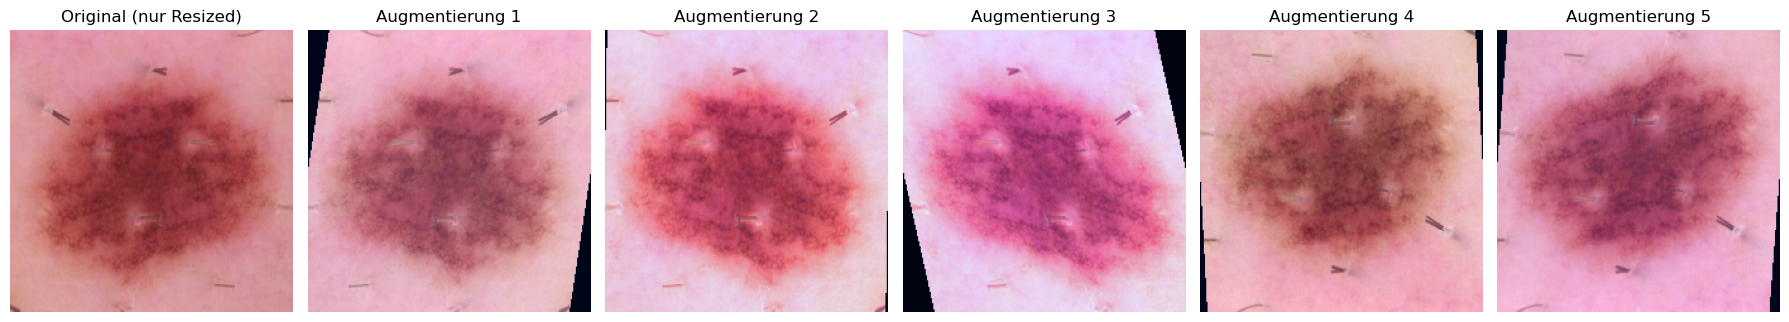

In [9]:
# Wir nehmen einfach den ersten Pfad aus deinem Datensatz (oder du wählst einen spezifischen Index)
sample_image_path = X_train_oversampled['path'].iloc[1] 
original_image = Image.open(sample_image_path).convert('RGB')

# --- 3. Plot mit Original und Variationen erstellen ---
num_variations = 5  # Wie viele augmentierte Bilder gezeigt werden sollen
fig, axes = plt.subplots(1, num_variations + 1, figsize=(18, 4))

# Originalbild anzeigen (nur auf 224x224 skaliert für einen fairen Vergleich)
resize_only = transforms.Resize((224, 224))
axes[0].imshow(resize_only(original_image))
axes[0].set_title("Original (nur Resized)", fontsize=12)
axes[0].axis('off')

# Augmentierte Versionen generieren und anzeigen
for i in range(1, num_variations + 1):
    # Durch den Aufruf von viz_transformer() werden die Zufallsoperationen jedes Mal neu berechnet
    aug_image = train_data_image_transformer(original_image)
    aug_image = aug_image.detach().cpu().permute(1, 2, 0).numpy()
    # Farben für Matplotlib in den Bereich [0, 1] zwingen , da die Bilder durch das normalize aus der 
    # Augmentierungspipline sonst nicht "menschlich" dargstellt werden.
    aug_image = (aug_image - aug_image.min()) / (aug_image.max() - aug_image.min() + 1e-8)

    axes[i].imshow(aug_image)
    axes[i].set_title(f"Augmentierung {i}", fontsize=12)
    axes[i].axis('off')

# Layout anpassen, damit die Bilder schön nebeneinander stehen
plt.tight_layout()
plt.show()

### Erstelle Datasets and loader
Die aufbereiteten Pipelines werden nun an die PyTorch-DataLoader übergeben, welche die Bilder für den Trainingsprozess in ressourcenschonende Batches unterteilen. (evtl. nochmal übberarbeiten wegen der Bachtes-Aussage)

In [57]:
train_dataset = HAM10000Dataset(
    X_train_oversampled['path'],
    y_train_oversampled,
    transform=train_data_image_transformer  # Deine Augmentierung
)

val_dataset = HAM10000Dataset(
    X_val['path'],
    y_val,
    transform=validation_data_image_transformer  # Nur Resize/Normalize
)

test_dataset = HAM10000Dataset(
    X_test['path'],
    y_test,
    transform=validation_data_image_transformer  # Nur Resize/Normalize
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # nur 32 Batchsize... sind das nicht zu wenig... wie funktioniert das?
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


## 3. Modelle erstellen
Um sicherzustellen, dass die XAI-Evaluation architekturübergreifend gültig ist und den Trade-off zwischen maximaler Performance und klinischer Effizienz abbildet, werden in dieser Arbeit zwei grundlegend unterschiedliche State-of-the-Art-Modelle implementiert: ResNet-101 und MobileNetV3. Da der Datensatz für ein Training von Grund auf nicht ausreicht, wird bei beiden Modellen auf Transfer Learning (vortrainierte ImageNet-Gewichte) zurückgegriffen.

### Resnet101 erstellen
Das ResNet-101 (Residual Network) repräsentiert in dieser Arbeit den massiven, parameterreichen Ansatz. Durch die Nutzung von "Shortcut-Connections" löst es das Problem der verschwindenden Gradienten und ermöglicht das Training extrem tiefer Netze. Es ist auf maximale Repräsentationskraft und höchste Klassifikationsgenauigkeit ausgelegt.

In [58]:
# 1. ResNet101 laden (Standard für Transfer Learning in der Literatur)
# Sangwan (2024) nutzt ResNet (ResNet50 und ResNet101)
resNet101Model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)

# Anzahl der Eingangs-Features holen (bei ResNet50 sind das 2048)
num_ftrs = resNet101Model.fc.in_features

# Den Classifier ersetzen => sangwan pseudocode
resNet101Model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),  # Reduktion der Dimension
    nn.ReLU(),  # Nicht-Linearität
    nn.Dropout(0.5),  # WICHTIG: Gegen Overfitting (siehe Sangwan)
    nn.Linear(512, 7)  # Output: 7 Klassen für HAM10000
)

### MobileNetV3 erstellen
Im direkten Kontrast dazu steht das MobileNetV3. Diese Architekturfamilie wurde speziell für den Einsatz auf ressourcenbeschränkten, mobilen Geräten entwickelt (z. B. für Smartphone-Dermatoskope am Patientenbett). Es nutzt effiziente tiefenweise separierbare Faltungen (Depthwise Separable Convolutions) und Attention-Module (Squeeze-and-Excitation), um mit einem Bruchteil der Parameter auszukommen. (Viel zu kompliziert!!!)

In [59]:
mobileNetV3Model = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)

# Den Classifier inspizieren und anpassen
# Der Classifier ist ein nn.Sequential Block.
# Struktur meist:
# (0): Linear (...)
# (1): Hardswish()
# (2): Dropout(...)
# (3): Linear (in_features=1280, out_features=1000)  
# Wir greifen auf die letzte Schicht zu
last_layer_index = len(mobileNetV3Model.classifier) - 1
in_features = mobileNetV3Model.classifier[last_layer_index].in_features

# Um Overfitting bei den relativ kleinen medizinischen Daten zu vermeiden,
# Dropout anpassen Hossain et al. (2024)
mobileNetV3Model.classifier[last_layer_index - 1] = nn.Dropout(p=0.3, inplace=True)

# Letzte Schicht auf 7 Klassen (HAM10000) anpassen
mobileNetV3Model.classifier[last_layer_index] = nn.Linear(in_features, 7)

## 4. Modelle trainieren
In diesem Schritt erfolgt das eigentliche Fine-Tuning der beiden Modelle. Die obersten Klassifikationsschichten der vortrainierten Netzwerke wurden auf die 7 Läsionsklassen des HAM10000-Datensatzes angepasst. Optimiert wird mit dem Adam-Optimizer und der Categorical Cross-Entropy als Verlustfunktion.

(Hinweis: Der Code-Block für das Training ist standardmäßig auskommentiert, da das Training auf einer Standard-Hardware mehrere Stunden in Anspruch nehmen kann. Die trainierten Gewichte werden stattdessen im nächsten Schritt geladen)

In [60]:
def fit(model, train_loader, val_loader, title, num_epochs=100, learning_rate=0.00001, early_stop_patience=10):
    """
    Implementierung der Trainingsschleife basierend auf Sangwan (2024).
    Nutzt Adam Optimizer und ReduceLROnPlateau.
    """
    # Definition der Loss-Funktion: "Categorical Cross Entropy"
    criterion = nn.CrossEntropyLoss()

    # WICHTIG: Wir übergeben dem Optimierer NUR die Parameter, die aufgetaut sind!
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    
    # Definition des Optimizers: "Adam"
    # Wir optimieren nur die Parameter, die requires_grad=True haben (unser neuer Classifier Head).
    # „Für das Training des Klassifikators wurde der Adam-Optimizer gewählt. Im Gegensatz zum klassischen Stochastic Gradient Descent (SGD)
    # nutzt Adam adaptive Lernraten, was in der Literatur (Kingma & Ba, 2014) und in der Referenzstudie von Sangwan (2024) mit einer
    # schnelleren Konvergenz des Modells begründet wird.“
    optimizer = optim.Adam(trainable_params, lr=learning_rate)

    # Learning Rate Scheduler: "Reduce on plateau was used"
    # Reduziert die Lernrate, wenn der Validation-Loss nicht mehr sinkt.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    model = model.to(device)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_precision = 0.0
    best_f1 = 0.0
    epochs_no_improve = 0
    
    print(f"Starte Training auf Gerät: {device} für {title}")
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        # Jede Epoche hat eine Trainings- und eine Validierungsphase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Modell in Trainingsmodus setzen
                dataloader = train_loader
            else:
                model.eval()  # Modell in Evaluierungsmodus setzen
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            
            # Listen zum Sammeln aller Vorhersagen und Labels dieser Epoche
            all_preds = []
            all_labels = []

            # Iteration über die Daten
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Parameter-Gradienten auf Null setzen
                optimizer.zero_grad()
                # Forward Pass
                # Nur im Trainings-Modus Gradienten berechnen (spart Speicher bei Val)
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward Pass und Optimierung nur in der Trainingsphase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                # echtes lernen nur bis hier
                # --------------------------------------
                # Statistiken sammeln
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Daten für Precision sammeln (auf CPU verschieben für scikit-learn)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            # Precision berechnen
            # average='weighted': Berücksichtigt das Ungleichgewicht der Klassen
            # zero_division=0: Verhindert Abstürze, falls eine Klasse gar nicht vorhergesagt wurde
            epoch_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Precision: {epoch_precision:.4f} F1-Score: {epoch_f1:.4f}')

            # Deep Copy des Modells, wenn es das beste bisher ist (basierend auf Val-Acc)
            if phase == 'val':
                scheduler.step(epoch_loss)  # Update Learning Rate basierend auf Val-Loss
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_precision = epoch_precision
                    best_f1 = epoch_f1
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0  # Counter zurücksetzen
                    print("Neues bestes Modell gespeichert!")
                else:
                    # Keine Verbesserung
                    epochs_no_improve += 1
                    print(f"Keine Verbesserung seit {epochs_no_improve} Epoche(n).")

        print()
        # --- Early Stopping Abbruchbedingung prüfen ---
        if epochs_no_improve >= early_stop_patience:
            print(f"Early Stopping ausgelöst! Keine Verbesserung der Validation Accuracy über {early_stop_patience} aufeinanderfolgende Epochen.")
            break # Bricht die äußere Epochen-Schleife ab

    print(f'Best Val Acc: {best_acc:.4f} Precision: {best_precision:.4f} F1-Score: {best_f1:.4f}')

    # Das beste Modell laden und zurückgeben
    model.load_state_dict(best_model_wts)
    return model

#### Modell MobileNetV3 trainieren
Vorsicht: Folgender Aufruf ist sehr zeitintensiv. (mehrere Stunden)

In [15]:
#Komplettes Netz einfrieren, nur Classifier auftauen!
for param in mobileNetV3Model.parameters():
    param.requires_grad = False
    
for param in mobileNetV3Model.classifier.parameters():
    param.requires_grad = True
    
mobileNetV3Model = fit(
    model=mobileNetV3Model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    title="MobileNetV3 Phase 1 (Warm-Up Kopf)", 
    num_epochs=20,             # Nur kurzes Aufwärmen
    learning_rate=0.001,       
    early_stop_patience=5      # Kann hier sehr kurz sein
)

print("\nEntfriere das gesamte Netzwerk für das Fine-Tuning...")

# Nur das letzte Viertel des Netzwerks auftauen!
# PyTorch's MobileNetV3 hat die Faltungsschichten im Block 'features'.
# Wir tauen nur die letzten 4 Blöcke auf (Index -4 bis Ende), der Rest bleibt sicher eingefroren!
for param in mobileNetV3Model.features[-4:].parameters():
    param.requires_grad = True

# Wir tauen nun das gesamte Netzwerk auf, um die tieferen Schichten an die 
# spezifischen Hautkrebs-Merkmale anzupassen ("and then all layers were trained 
# to fine-tune the models" - Alfi et al., 2022).
for param in mobileNetV3Model.parameters():
    param.requires_grad = True

# Jetzt starten wir das eigentliche lange Training. 
# WICHTIG: Die Lernrate MUSS jetzt mikroskopisch klein sein, da wir das 
# Netz nur "feinjustieren" und nicht aus dem Konzept bringen wollen!
mobileNetV3Model = fit(
    model=mobileNetV3Model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    title="MobileNetV3 Phase 2 (Full Fine-Tuning)", 
    num_epochs=50,             # Jetzt dürfen es mehr Epochen sein
    learning_rate=1e-5,        # extrem wichtig für Fine-Tuning!
    early_stop_patience=10     # Jetzt greift das eigentliche Early Stopping
)

torch.save(mobileNetV3Model.state_dict(), MODEL_MOBILE_NET_V3_FILE_PATH)

Starte Training auf Gerät: cuda für MobileNetV3 Phase 1 (Warm-Up Kopf)
Epoch 1/20
----------
train Loss: 0.9196 Acc: 0.6465 Precision: 0.6434 F1-Score: 0.6434
val Loss: 0.7042 Acc: 0.7486 Precision: 0.7698 F1-Score: 0.7515
Neues bestes Modell gespeichert!

Epoch 2/20
----------
train Loss: 0.8394 Acc: 0.6825 Precision: 0.6815 F1-Score: 0.6813
val Loss: 0.7452 Acc: 0.7298 Precision: 0.7711 F1-Score: 0.7444
Keine Verbesserung seit 1 Epoche(n).

Epoch 3/20
----------
train Loss: 0.8027 Acc: 0.6886 Precision: 0.6875 F1-Score: 0.6873
val Loss: 0.6866 Acc: 0.7514 Precision: 0.7839 F1-Score: 0.7599
Neues bestes Modell gespeichert!

Epoch 4/20
----------
train Loss: 0.7593 Acc: 0.7092 Precision: 0.7086 F1-Score: 0.7086
val Loss: 0.7051 Acc: 0.7486 Precision: 0.7880 F1-Score: 0.7622
Keine Verbesserung seit 1 Epoche(n).

Epoch 5/20
----------
train Loss: 0.7383 Acc: 0.7184 Precision: 0.7179 F1-Score: 0.7178
val Loss: 0.7061 Acc: 0.7566 Precision: 0.7781 F1-Score: 0.7571
Neues bestes Modell gespe

#### Modell ResNet101 trainieren
Vorsicht: Folgender Aufruf ist sehr zeitintensiv. (mehrere Stunden)

In [16]:
# ALLES einfrieren (Basis-Wissen bewahren)...
for param in resNet101Model.parameters():
    param.requires_grad = False
    
# ... bis auf die letzten Layer
for param in resNet101Model.layer4.parameters():
    param.requires_grad = True

for param in resNet101Model.fc.parameters():
    param.requires_grad = True

resNet101Model = fit(
    model=resNet101Model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    title="ResNet101 Phase 1 (Warm-Up Kopf)", 
    num_epochs=20,             # Nur kurzes Aufwärmen
    learning_rate=0.001,       
    early_stop_patience=5      # Kann hier sehr kurz sein
)

print("\nEntfriere das gesamte Netzwerk für das Fine-Tuning...")

# Wir tauen nun das gesamte Netzwerk auf, um die tieferen Schichten an die 
# spezifischen Hautkrebs-Merkmale anzupassen ("and then all layers were trained 
# to fine-tune the models" - Alfi et al., 2022).
for param in resNet101Model.parameters():
    param.requires_grad = True

# Jetzt starten wir das eigentliche lange Training. 
# WICHTIG: Die Lernrate MUSS jetzt mikroskopisch klein sein, da wir das 
# Netz nur "feinjustieren" und nicht aus dem Konzept bringen wollen!
resNet101Model = fit(
    model=resNet101Model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    title="ResNet101 Phase 2 (Full Fine-Tuning)", 
    num_epochs=50,             # Jetzt dürfen es mehr Epochen sein
    learning_rate=1e-5,        # extrem wichtig für Fine-Tuning!
    early_stop_patience=10     # Jetzt greift das eigentliche Early Stopping
)

torch.save(resNet101Model.state_dict(), MODEL_RESNET101_FILE_PATH)

Starte Training auf Gerät: cuda für ResNet101 Phase 1 (Warm-Up Kopf)
Epoch 1/20
----------
train Loss: 0.9654 Acc: 0.6387 Precision: 0.6358 F1-Score: 0.6317
val Loss: 0.5117 Acc: 0.8195 Precision: 0.8083 F1-Score: 0.8070
Neues bestes Modell gespeichert!

Epoch 2/20
----------
train Loss: 0.6297 Acc: 0.7682 Precision: 0.7678 F1-Score: 0.7676
val Loss: 0.4876 Acc: 0.8261 Precision: 0.8283 F1-Score: 0.8259
Neues bestes Modell gespeichert!

Epoch 3/20
----------
train Loss: 0.5047 Acc: 0.8142 Precision: 0.8144 F1-Score: 0.8141
val Loss: 0.5006 Acc: 0.8261 Precision: 0.8368 F1-Score: 0.8285
Keine Verbesserung seit 1 Epoche(n).

Epoch 4/20
----------
train Loss: 0.4009 Acc: 0.8531 Precision: 0.8533 F1-Score: 0.8531
val Loss: 0.5320 Acc: 0.8214 Precision: 0.8301 F1-Score: 0.8244
Keine Verbesserung seit 2 Epoche(n).

Epoch 5/20
----------
train Loss: 0.3535 Acc: 0.8704 Precision: 0.8707 F1-Score: 0.8705
val Loss: 0.5757 Acc: 0.7989 Precision: 0.8367 F1-Score: 0.8099
Keine Verbesserung seit 3 E

## 5. Vortrainierte Modelle laden
Hier laden wir die Gewichte der fertig trainierten Modelle (.pth oder .pt Dateien). Dies ermöglicht eine exakte Reproduzierbarkeit der späteren Erklärungsgenerierung, ohne das Modell jedes Mal neu trainieren zu müssen.

In [61]:
loaded_data_resnet101 = torch.load(MODEL_RESNET101_FILE_PATH)
resNet101Model.load_state_dict(loaded_data_resnet101)

loaded_data_mobilenetv3 = torch.load(MODEL_MOBILE_NET_V3_FILE_PATH)
mobileNetV3Model.load_state_dict(loaded_data_mobilenetv3)

C:\Users\jalle\AppData\Local\Temp\ipykernel_3760\2924343579.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_data_resnet101 = torch.load(MODEL_RESNET101_FILE_PATH)

<All keys matched successfully>

## 6. Modelle gegen den Testdatensatz validieren
Bevor die Black-Box geöffnet und erklärt wird, muss sichergestellt sein, dass die Modelle diagnostisch auf hohem Niveau agieren. In diesem Schritt wird die Performance (Accuracy, Precision, Recall, F1-Score) beider Modelle auf dem ungesehenen Testdatensatz berechnet.

Starte Evaluation für ResNet101 auf dem Testdatensatz...

=== Gesamtergebnis für ResNet101 ===
Test Accuracy: 0.8743 (87.43%)

=== Detaillierter Klassifikationsbericht ===
              precision    recall  f1-score   support

       akiec     0.7308    0.7755    0.7525        49
         bcc     0.8101    0.8312    0.8205        77
         bkl     0.7857    0.7333    0.7586       165
          df     0.8571    0.7059    0.7742        17
         mel     0.7615    0.5928    0.6667       167
          nv     0.9118    0.9553    0.9330      1006
        vasc     0.9500    0.8636    0.9048        22

    accuracy                         0.8743      1503
   macro avg     0.8296    0.7797    0.8015      1503
weighted avg     0.8701    0.8743    0.8704      1503

Erstelle Confusion Matrix für ResNet101...
array([[ 38,   2,   4,   0,   2,   3,   0],
       [  3,  64,   4,   1,   1,   4,   0],
       [  8,   3, 121,   0,   5,  28,   0],
       [  0,   1,   1,  12,   0,   3,   0],
       [  1,

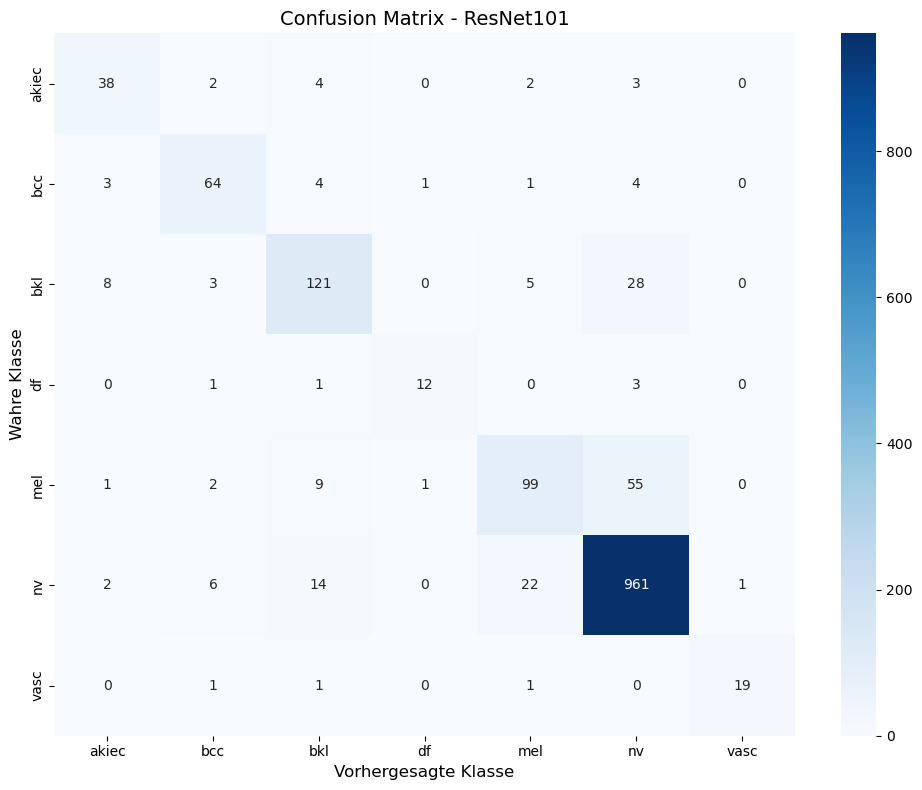

Starte Evaluation für MobileNetV3 auf dem Testdatensatz...

=== Gesamtergebnis für MobileNetV3 ===
Test Accuracy: 0.8323 (83.23%)

=== Detaillierter Klassifikationsbericht ===
              precision    recall  f1-score   support

       akiec     0.6591    0.5918    0.6237        49
         bcc     0.6883    0.6883    0.6883        77
         bkl     0.6500    0.7091    0.6783       165
          df     0.8182    0.5294    0.6429        17
         mel     0.6357    0.5329    0.5798       167
          nv     0.9070    0.9304    0.9185      1006
        vasc     0.9474    0.8182    0.8780        22

    accuracy                         0.8323      1503
   macro avg     0.7579    0.6857    0.7156      1503
weighted avg     0.8289    0.8323    0.8294      1503

Erstelle Confusion Matrix für MobileNetV3...
array([[ 29,   5,  11,   0,   3,   1,   0],
       [  2,  53,   6,   1,   5,   9,   1],
       [  9,   5, 117,   1,   7,  26,   0],
       [  0,   4,   0,   9,   1,   3,   0],
      

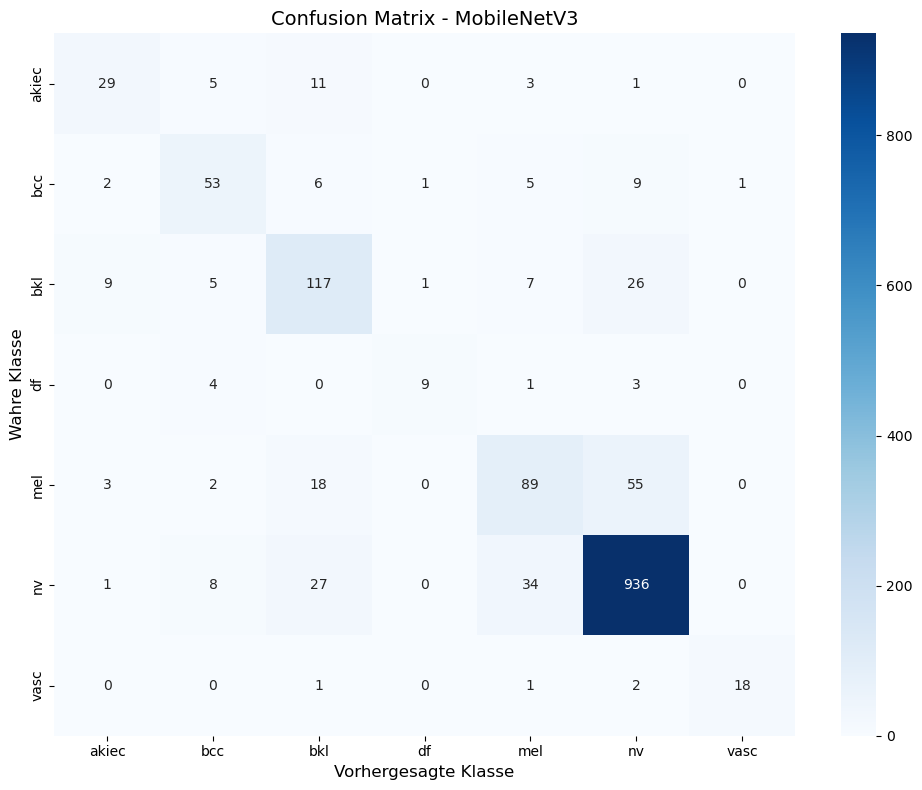

In [62]:
"""
Berechnet Accuracy, Precision, Recall und F1 auf dem Testset.
"""
resNet101Model.eval()  # Wichtig: Evaluation Modus
resNet101Model.to(device)

mobileNetV3Model.eval()  # Wichtig: Evaluation Modus
mobileNetV3Model.to(device)

def evaluateTestData(model, title):
    all_preds = []
    all_labels = []
    
    print(f"Starte Evaluation für {title} auf dem Testdatensatz...")
    
    with torch.no_grad():  # Keine Gradientenberechnung nötig
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            # Vorhersage
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
    
            # Sammeln der Ergebnisse (zurück auf CPU schieben)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # --- Berechnung der Metriken ---
    
    # 1. Gesamte Accuracy (Top-1)
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n=== Gesamtergebnis für {title} ===")
    print(f"Test Accuracy: {acc:.4f} ({acc * 100:.2f}%)")
    class_names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
    # 2. Detaillierter Bericht (Precision, Recall, F1 pro Klasse)
    # Dies entspricht Table 3 in Sangwan (2024)
    print("\n=== Detaillierter Klassifikationsbericht ===")
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4  # 4 Nachkommastellen für Präzision
    )
    print(report)

    # 3. Confusion Matrix
    print(f"Erstelle Confusion Matrix für {title}...")
    cm = confusion_matrix(all_labels, all_preds)
    print(repr(cm))
    
    print("\n" + "="*40 + "\n")
    
    # Visualisierung der Confusion Matrix mit Seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f'Confusion Matrix - {title}', fontsize=14)
    plt.ylabel('Wahre Klasse', fontsize=12)
    plt.xlabel('Vorhergesagte Klasse', fontsize=12)
    
    # Layout anpassen und anzeigen
    plt.tight_layout()
    plt.show()

evaluateTestData(resNet101Model, "ResNet101")
evaluateTestData(mobileNetV3Model, "MobileNetV3")

## 7. XAI
Dies ist der methodische Kern des Notebooks. Die zuvor validierten Black-Box-Modelle werden nun mithilfe zweier konzeptionell gegensätzlicher XAI-Methoden durchleuchtet. Das Ziel ist es, die generierten Heatmaps nicht nur visuell zu betrachten, sondern objektiv und quantitativ zu messen.

### Methode zum Erstellen der XAI-Evaluations-True-Positive-Bilder
Warum Metriken (wie IROF) auf True Positives beschränkt werden sollten: Wenn man quantitativ messen will, ob Grad-CAM oder LIME die bessere Methode ist, müssen Sie die Fehlerhaftigkeit des neuronalen Netzes von der Fehlerhaftigkeit der XAI-Methode trennen. Wenn ein Modell eine komplett falsche Vorhersage trifft (False Negative oder False Positive), ist die zugrunde liegende Entscheidung per se inkorrekt. Wenn Grad-CAM nun bei einem übersehenen Melanom auf einen völlig irrelevanten Hautbereich zeigt, ist es mathematisch unmöglich zu trennen, ob Grad-CAM als Erklärungsmethode versagt hat, oder ob das Modell bei diesem Bild schlichtweg unsinnige Merkmale gelernt hat. (Zou et al. (2023))

In [14]:
def get_xai_loader(model, num_images=60):
    """
    Erstellt einen DataLoader mit exakt 'num_images' True Positives für ein spezifisches Modell.
    """
    model.eval()
    tp_indices = []
    all_targets = []
        
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Vorhersage des Modells
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            # Finde Indizes, wo Vorhersage == Wahrheit (True Positives)
            matches = (predicted == targets).cpu().numpy()
            
            # Speichere die globalen Indizes des Datasets und die dazugehörigen Labels
            start_idx = batch_idx * test_loader.batch_size
            for i, match in enumerate(matches):
                if match:
                    tp_indices.append(start_idx + i)
                    all_targets.append(targets[i].item())

    # Ziehe exakt 60 Bilder (stratifiziert, falls möglich)
    xai_indices, _ = train_test_split(
        tp_indices, 
        train_size=num_images, 
        stratify=all_targets, 
        random_state=42 # Fixer Seed für Reproduzierbarkeit
    )

    # Erstelle ein PyTorch Subset aus den originalen Testdaten
    xai_dataset = Subset(test_dataset, xai_indices)
    
    # Erstelle den finalen DataLoader (Batch-Size entspricht oft num_images für die Quantus-Metriken)
    return DataLoader(xai_dataset, batch_size=num_images, shuffle=False)

### Definiere Quantus-Metriken
Für die objektive Bewertung der XAI-Verfahren nutzen wir das Quantus-Framework. Wir definieren hier Metriken zur Evaluation der Robustheit (Stabilität der Erklärung bei minimalen Bildstörungen) und der Erklärungstreue / Faithfulness (wie präzise die Erklärung den wahren Modellentscheidungsprozess widerspiegelt, z. B. durch iteratives Entfernen wichtiger Pixel).

In [15]:
import quantus

# QUANTUS-BUGFIX
def patched_perturb_func(arr, mask, **kwargs):
    """
    Fängt den Quantus-internen Shape-Bug ab, indem die 1-Kanal-Maske 
    auf die 3 Farbkanäle des Bildes dupliziert wird.
    """
    if arr.shape != mask.shape and mask.shape[1] == 1:
        mask = np.repeat(mask, arr.shape[1], axis=1)
        
    return quantus.functions.perturb_func.baseline_replacement_by_mask(arr, mask, **kwargs)

# FAITHFULNESS
metric_irof = quantus.IROF(
    #perturb_baseline="mean", is default =>  Rieger und Hansen betonen, dass es essenziell ist, die entfernten Bildsegmente durch den Mittelwert des Datensatzes zu ersetzen und nicht durch Rauschen (Uniform Noise) oder schwarze Pixel
#. Rauschen würde das Bild so stark verfälschen, dass es außerhalb der gelernten Datenverteilung ("out-of-distribution") liegt
#. Man würde dann nicht mehr messen, ob das Feature wichtig war, sondern nur, dass das CNN durch künstliches Rauschen verwirrt wird

    perturb_func=patched_perturb_func,
    return_aggregate=False,
    disable_warnings=True
)

# ROBUSTNESS
metric_robustness = quantus.LocalLipschitzEstimate(
    nr_samples=20,  # EMPFEHLUNG 20: Anlehung an Sangwan "Runs=20"
    disable_warnings=True
)

metrics = {
    "Faithfulness": metric_irof,
    "Robustness": metric_robustness
}

### Helferfunktionen

In [16]:
# Eine kleine Helferfunktion, um die Ergebnisse der Metriken darzustellen.
def score_display_helper(scores):
    scores_array = np.array(scores).flatten()
    
    # Metriken berechnen
    mean_score = np.mean(scores_array)
    std_score = np.std(scores_array)
    min_score = np.min(scores_array)
    max_score = np.max(scores_array)

    formatted_scores = [f"{s:.4f}" for s in scores_array]
    scores_str = ", ".join(formatted_scores) 

    print(f"    Statistik: Mean: {mean_score:.4f} | Std: {std_score:.4f} | Min: {min_score:.4f} | Max: {max_score:.4f}")
    print(f"    Einzel-Scores: [{scores_str}]")

In [17]:
# Box-Plot Helferfunkton
def plot_xai_comparison(results_gradcam, results_lime, metric_name):
    # Ergebnisse zusammenführen
    data = [results_gradcam, results_lime]
    labels = ['Grad-CAM', 'LIME']
    
    plt.figure(figsize=(8, 6))
    
    # Den Box-and-Whisker-Plot erstellen
    bp = plt.boxplot(data, tick_labels=labels, patch_artist=True)
    
    # Ein bisschen Farbe für die Thesis
    colors = ['#005EA6', '#FFB6C1'] # blau für Grad-CAM, Hellrosa für LIME
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        
    plt.title(f'Vergleich: {metric_name}', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

### Definiere Lime
Als Repräsentant der perturbationsbasierten Ansätze implementieren wir hier LIME (Local Interpretable Model-agnostic Explanations). LIME behandelt das CNN als Black-Box, unterteilt das Bild in Superpixel und maskiert diese systematisch, um zu messen, wie sich die Modellvorhersage verändert. Die Hyperparameter (Anzahl der Segmente und Perturbationen) sind kritisch für die Qualität der Erklärung.

In [18]:
def get_lime_explainer(model):
    # LIME benötigt ein lokales, interpretierbares Modell (Standard: Lineare Regression)
    explainer = Lime(model, interpretable_model=SkLearnLinearRegression())

    def wrapper(model, inputs, targets, **kwargs):
        model.eval()
        inputs = torch.as_tensor(inputs, device=device)
        targets = torch.as_tensor(targets, device=device)

        batch_size = inputs.shape[0]
        attrs = []

        # WICHTIG: LIME muss die Bilder einzeln verarbeiten,
        # da die Superpixel (Segmente) spezifisch pro Bild generiert werden.
        for i in range(batch_size):
            single_input = inputs[i:i+1]  # Shape: (1, C, H, W)
            single_target = targets[i:i+1]

            # 1. Bild für die Superpixel-Berechnung vorbereiten
            # Skimage erwartet das Format (H, W, C) als Numpy-Array
            img_np = single_input[0].detach().cpu().numpy().transpose(1, 2, 0)
            
            # Normalisieren (0 bis 1) für eine saubere Segmentierung
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

            # 2. Superpixel (Segmente) generieren
            # n_segments bestimmt die Granularität. Sangwan betont, dass Hyperparameter
            # von Erklärungsalgorithmen die Qualität signifikant beeinflussen.
            segments = slic(img_np, n_segments=250, compactness=10, start_label=0)

            # Feature-Maske in das von Captum erwartete Tensor-Format bringen: (1, 1, H, W)
            feature_mask = torch.tensor(segments, device=device).unsqueeze(0).unsqueeze(0)

            # 3. LIME Attribute berechnen
            # n_samples = Anzahl der Perturbationen (Je höher, desto stabiler, aber deutlich langsamer)
            attr = explainer.attribute(
                single_input,
                target=single_target,
                feature_mask=feature_mask,
                n_samples=5000 # (Ribeiro et al., 2016) nutzten für die Bildklassifikation beispielsweise oft 5.000 Samples 
            )

            # Über die Farbkanäle summieren, um eine 2D-Heatmap zu erhalten (analog zu Grad-CAM)
            attr = attr.sum(dim=1)
            attrs.append(attr)

        # Den Batch wieder zusammensetzen
        batch_attr = torch.cat(attrs, dim=0)
        return batch_attr.detach().cpu().numpy()

    return wrapper

def evaluateLIME(model, x_batch, y_batch):
    print("-" * 30)
    print("Evaluate LIME metric...")

    results = {}
    for key in metrics:
        print(f"  -> Running metric: {key}")
        start = time.time()
        scores = metrics[key](
            model=model,
            x_batch=x_batch,
            y_batch=y_batch,
            device=device,
            explain_func=get_lime_explainer(model),
        )
        end = time.time()
        results[key] = scores;
        print(f"    Dauer: {end - start:.2f}s")
        score_display_helper(scores)
        print()
    return results

### Definiere Grad-CAM
Als Repräsentant der gradientenbasierten Ansätze wird Grad-CAM (Gradient-weighted Class Activation Mapping) definiert. Es schaut direkt in die Architektur des CNNs und berechnet die Heatmap aus dem Gradientenfluss der letzten Faltungsschicht in nur einem einzigen Vorwärts- und Rückwärtsdurchlauf.

In [19]:
def get_gradcam_explainer(model, target_layer):
    explainer = LayerGradCam(model, target_layer)

    def wrapper(model, inputs, targets, **kwargs):
        model.eval()

        device = next(model.parameters()).device
        inputs = torch.as_tensor(inputs, device=device)
        targets = torch.as_tensor(targets, device=device)

        # Wichtig: Gradienten nullen, um Akkumulation zu verhindern
        model.zero_grad()

        attr = explainer.attribute(inputs, target=targets)
        
        # Upsampling & Transformation
        attr = F.interpolate(attr, size=inputs.shape[2:], mode='bilinear', align_corners=False)

        return attr.detach().cpu().numpy()

    return wrapper


def evaluateGradCAM(model, x_batch, y_batch, model_target_layer):
    print("-" * 30)
    print("Evaluate Grad-CAM metric...")

    results = {}
    for key in metrics:
        print(f"  -> Running metric: {key}")
        start = time.time()
        scores = metrics[key](
            model=model,
            x_batch=x_batch,
            y_batch=y_batch,
            device=device,
            explain_func=get_gradcam_explainer(model, model_target_layer),
        )
        end = time.time()
        results[key] = scores;
        print(f"    Dauer: {end - start:.2f}s")
        score_display_helper(scores)
        print()
    return results


### Evaluiere XAI mit Quantus-Metriken
In dieser finalen Evaluationsschleife werden Grad-CAM und LIME auf einer gezielten Stichprobe des Testdatensatzes angewendet. Es wird berechnet, welches Grundkonzept – Gradienten oder Perturbation – auf dem jeweiligen Modell (ResNet vs. MobileNet) die treueren und robusteren Erklärungen liefert und wie sich der signifikante Unterschied im Rechenaufwand verhält.

In [ ]:
def get_eval_data(dataloader, num_samples):
    """Zieht exakt num_samples Bilder am Stück aus dem Dataloader."""
    x_list, y_list = [], []
    collected = 0
    
    for inputs, labels in dataloader:
        x_list.append(inputs)
        y_list.append(labels)
        collected += len(inputs)
        if collected >= num_samples:
            break
            
    # Tensoren zusammenfügen und exakt auf num_samples abschneiden
    x_tensor = torch.cat(x_list, dim=0)[:num_samples]
    y_tensor = torch.cat(y_list, dim=0)[:num_samples]
    
    return x_tensor.numpy(), y_tensor.numpy()

def evaluateXai(model, target_layer, title, max_gradcam=32, max_lime=10):
    print(f"\n{'='*40}")
    print(f"Starte Evaluation - {title}")
    print(f"{'='*40}")
    
    model = model.to(device)
    
    # 1. Datenbeschaffung
    # Bilder aufteilen (LIME testet exakt dieselben ersten Bilder wie Grad-CAM)
    xai_image_loader = get_xai_loader(model)
    print(f"Lade {max_gradcam} Bilder aus dem Test-Loader für Grad-CAM...")
    
    x_gradcam, y_gradcam = get_eval_data(xai_image_loader, max_gradcam)

    print(f"Lade {max_lime} Bilder aus dem Test-Loader für Lime...")
    x_lime, y_lime = get_eval_data(xai_image_loader, max_lime)
    
    # 2. Grad-CAM Evaluierung (Alles in einem Rutsch)
    print(f"\n-> Evaluiere Grad-CAM ({len(x_gradcam)} Bilder)...")
    results_gradcam = evaluateGradCAM(model, x_gradcam, y_gradcam, target_layer)
        
    # 3. LIME Evaluierung (Alles in einem Rutsch)
    print(f"\n-> Evaluiere LIME ({len(x_lime)} Bilder)...")
    results_lime = evaluateLIME(model, x_lime, y_lime)
    
    for key in metrics:
        plot_xai_comparison(results_gradcam[key], results_lime[key], key)
    
    print(f"\nEvaluation für {title} abgeschlossen!")

# Aufruf: GradCam und Lime später mit 60 Bildern. Das ist sehr Zeitintensiv (für Lime > 12 Std. mal 2 für Resnet und MobileNet)
evaluateXai(resNet101Model, resNet101Model.layer4[-1], "ResNet101", max_gradcam=32, max_lime=32)
evaluateXai(mobileNetV3Model, mobileNetV3Model.features[-1], "MobileNetV3", max_gradcam=32, max_lime=32)

### Zeiten messen für Grad-CAM und LIME

In [52]:
def measure_xai_performance(model, img, target, target_layer, iterations=10):
    # Vorbereitung der Explainer
    gradcam_func = get_gradcam_explainer(model, target_layer)
    # Falls du einen LIME-Explainer hast, hier definieren:
    lime_explainer = get_lime_explainer(model)
    
    gradcam_times = []
    lime_times = []

    print(f"Starte Benchmark ({iterations} Durchläufe)...")

    for i in range(iterations):
        # --- Messung Grad-CAM ---
        start = time.perf_counter()
        _ = gradcam_func(model, img, target)
        end = time.perf_counter()
        gradcam_times.append(end - start)
        
        # --- Messung LIME (Beispielhafter Aufruf) ---
        start = time.perf_counter()
        _ = lime_explainer(model, img, target)
        end = time.perf_counter()
        lime_times.append(end - start)
        
        print(f"Durchlauf {i+1}/{iterations} abgeschlossen.", end="\r")

    # Statistiken berechnen
    gc_mean = np.mean(gradcam_times)
    gc_std = np.std(gradcam_times)
    
    print(f"\n\nErgebnisse für Grad-CAM:")
    print(f"Mittelwert: {gc_mean:.4f} Sekunden")
    print(f"Standardabweichung: {gc_std:.4f} Sekunden\n")

    print(f"{'='*40}")

    lime_mean = np.mean(lime_times)
    lime_std = np.std(lime_times)
    print(f"\nErgebnisse für LIME:")
    print(f"Mittelwert: {lime_mean:.4f} Sekunden")
    print(f"Standardabweichung: {lime_std:.4f} Sekunden")

img_idx=1
xai_mobilenet_image_loader = get_xai_loader(mobileNetV3Model)
data_iter = iter(xai_mobilenet_image_loader)
images, labels = next(data_iter)
input_img = images[img_idx: img_idx+1].to(device)
target = labels[img_idx: img_idx+1].to(device)

measure_xai_performance(mobileNetV3Model, input_img, target, mobileNetV3Model.features[-1])

Starte Benchmark (10 Durchläufe)...
Durchlauf 10/10 abgeschlossen.

Ergebnisse für Grad-CAM:
Mittelwert: 0.0113 Sekunden
Standardabweichung: 0.0014 Sekunden


Ergebnisse für LIME:
Mittelwert: 37.8305 Sekunden
Standardabweichung: 0.9381 Sekunden


## 8. Visualisierungen

### Heatmap-Visualisierung eines Beispielbildes
Um die berechneten quantitativen Metriken in einen praktischen Kontext zu setzen, werden in diesem Schritt die originalen Eingabebilder gemeinsam mit den generierten Heatmaps von LIME und Grad-CAM nebeneinander geplottet. Dies veranschaulicht visuell den Unterschied zwischen der feingranularen gradientenbasierten Segmentierung und der gröberen superpixel-basierten Maskierung der Modelle.

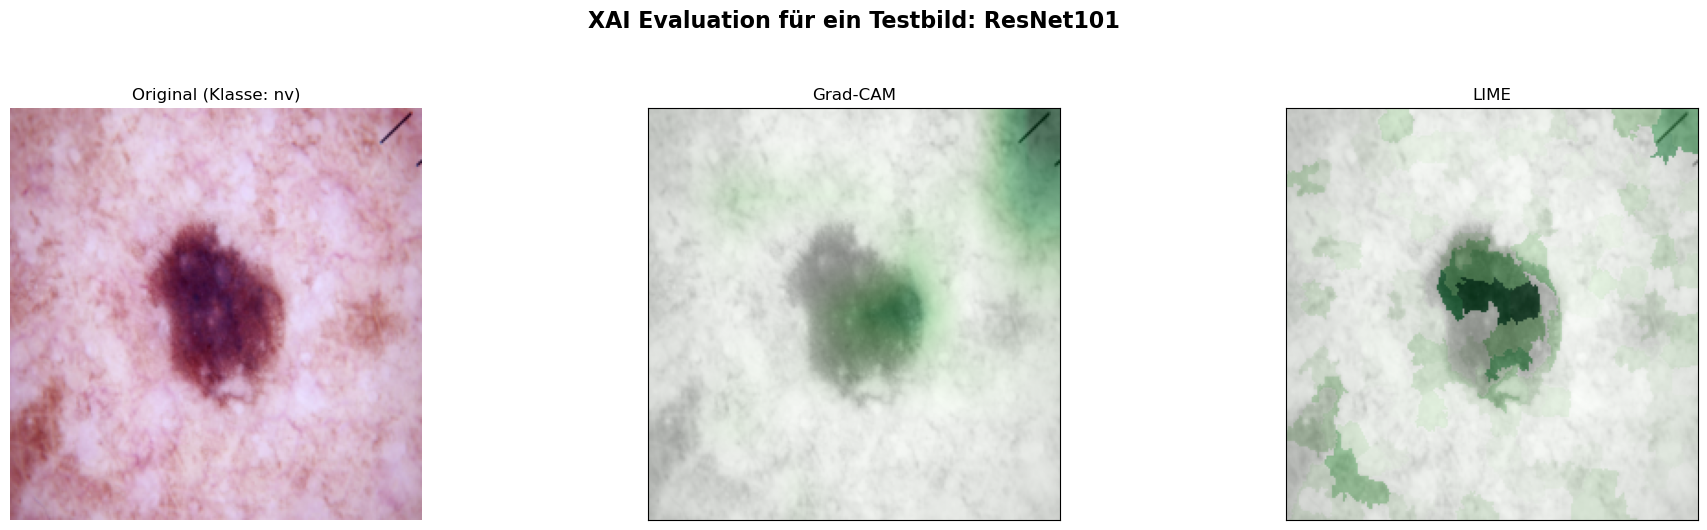

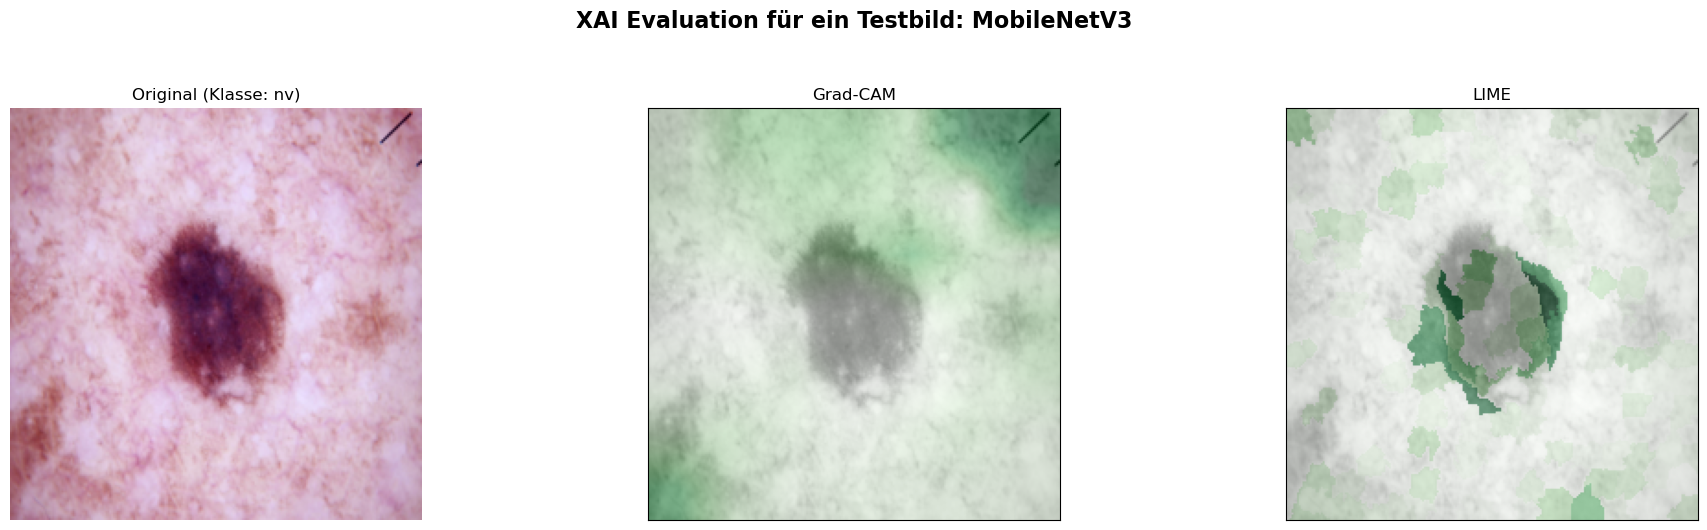

In [20]:
def visualize_explanations(model, images, labels, target_layer, title, img_idx=0):

   # 1. Daten vorbereiten (Direkt 1 Bild auswählen)
    input_img = images[img_idx: img_idx+1].to(device)
    target = labels[img_idx: img_idx+1].to(device)
    
    # --- DIE TENSOR-GYMNASTIK ---
    # Bild für den Plot vorbereiten: Von GPU auf CPU, zu Numpy, Format drehen (H,W,C)
    img_for_plot = input_img[0].detach().cpu().permute(1, 2, 0).numpy()
    # Farben für Matplotlib in den Bereich [0, 1] zwingen
    img_for_plot = (img_for_plot - img_for_plot.min()) / (img_for_plot.max() - img_for_plot.min() + 1e-8)
    # ----------------------------

    # 2. Erklärungen generieren
    # --- Grad-CAM ---
    gradcam_func = get_gradcam_explainer(model, target_layer)
    attr_gradcam = gradcam_func(model, input_img, target)[0] 
    attr_gradcam = attr_gradcam.transpose(1, 2, 0)
    
    # --- LIME ---
    lime_func = get_lime_explainer(model)
    attr_lime = lime_func(model, input_img, target)[0] 
    attr_lime = np.expand_dims(attr_lime, axis=-1)
    
    # 3. Visualisierung
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"XAI Evaluation für ein Testbild: {title}", fontsize=16, fontweight='bold', y=1.05)
    
    # Originalbild plotten
    label_remapped = {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
    axs[0].imshow(img_for_plot)
    axs[0].set_title(f"Original (Klasse: {label_remapped[target.item()]})")
    axs[0].axis('off')
    
    # Grad-CAM plotten
    viz.visualize_image_attr(
        attr_gradcam, img_for_plot, method="blended_heat_map", sign="positive",
        show_colorbar=False, use_pyplot=False, title="Grad-CAM", plt_fig_axis=(fig, axs[1])
    )
    
    # LIME plotten
    viz.visualize_image_attr(
        attr_lime, img_for_plot, method="blended_heat_map", sign="positive",
        show_colorbar=False, use_pyplot=False, title="LIME", plt_fig_axis=(fig, axs[2])
    )
    
    plt.tight_layout()
    plt.show()


resNet101Model.to(device)
mobileNetV3Model.to(device)

# Bilder nur aus dem MobileNetV3Loader nehmen, sodass für Resnet101 und MobileNetBV3 die gleichen Bilder verwendet werden.
xai_mobilenet_image_loader = get_xai_loader(mobileNetV3Model)
data_iter = iter(xai_mobilenet_image_loader)
images, labels = next(data_iter)

visualize_explanations(resNet101Model, images, labels, resNet101Model.layer4[-1], "ResNet101", 3)
visualize_explanations(mobileNetV3Model, images, labels, mobileNetV3Model.features[-1],"MobileNetV3", 3)



### Beispiel Segmentierung für IROF

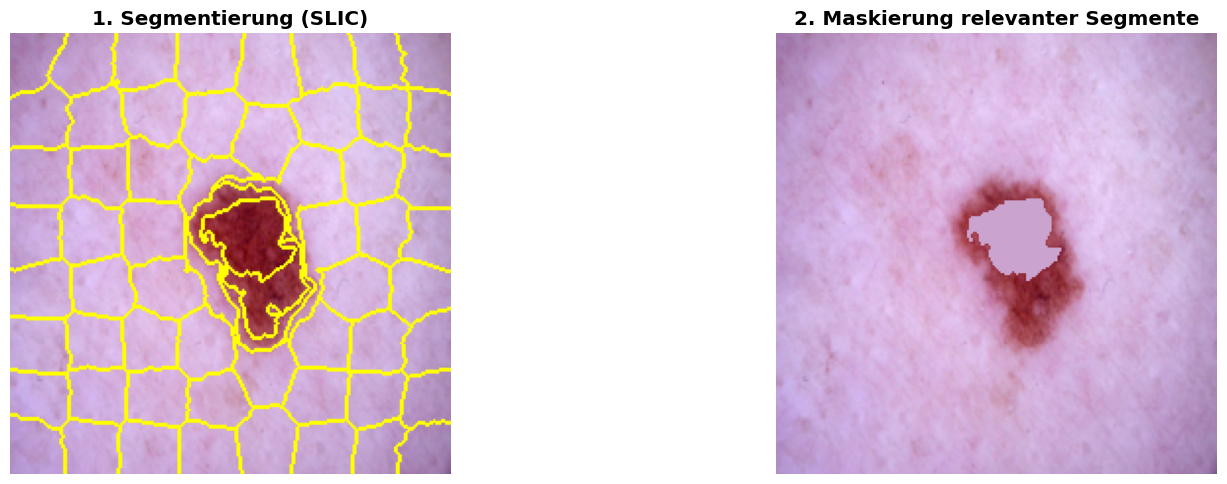

In [54]:
img_idx = 3
xai_mobilenet_image_loader = get_xai_loader(mobileNetV3Model)
data_iter = iter(xai_mobilenet_image_loader)
images, labels = next(data_iter)

img_tensor = images[img_idx]
img_np = img_tensor.cpu().numpy()
img = np.transpose(img_np, (1, 2, 0))
img = (img - img.min()) / (img.max() - img.min())

model = mobileNetV3Model.to(device)
model.eval()

global_mean_color = img.mean(axis=(0, 1))

# Superpixel-Segmentierung (SLIC)
# n_segments definiert die ungefähre Anzahl der Superpixel
segments = slic(img, n_segments=60, compactness=15, sigma=1, start_label=1)

# Simulation der Relevanz (XAI-Methode) & Maskierung
# Wir berechnen den Abstand jedes Segments zum Zentrum.
segment_ids = np.unique(segments)
relevance_scores = []
for seg_id in segment_ids:
    coords = np.column_stack(np.where(segments == seg_id))
    center_y, center_x = coords.mean(axis=0)
    dist_to_center = np.sqrt((center_x - 112)**2 + (center_y - 112)**2)
    relevance_scores.append(-dist_to_center) # Näher am Zentrum = höhere Relevanz

# Sortieren der Segmente nach Relevanz (absteigend)
sorted_seg_indices = np.argsort(relevance_scores)[::-1]
sorted_segments = segment_ids[sorted_seg_indices]

# Maskieren der Top 30% der relevantesten Segmente mit dem globalen Mean
# (Mean Imputation nach Rieger & Hansen, 2020)
masked_img = img.copy()
global_mean_color = img.mean(axis=(0, 1))
num_to_mask = int(len(segment_ids) * 0.03)

top_segments_to_mask = sorted_segments[:num_to_mask]
for seg_id in top_segments_to_mask:
    masked_img[segments == seg_id] = global_mean_color

# ==========================================
# 4. Simulation der AOC-Kurve (Modell-Konfidenz)
# ==========================================
fractions = np.linspace(0, 1, 10)

# ==========================================
# 5. Plotten der Schematischen Abbildung
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plt.rcParams.update({'font.size': 12})

# Plot 1: Originalbild mit Superpixeln
img_with_boundaries = mark_boundaries(img, segments, color=(1, 1, 0), mode='thick')
axes[0].imshow(img_with_boundaries)
axes[0].set_title("1. Segmentierung (SLIC)", fontweight='bold')
axes[0].axis('off')

# Plot 2: Iterative Maskierung (Mean Imputation)
axes[1].imshow(masked_img)
axes[1].set_title("2. Maskierung relevanter Segmente", fontweight='bold')
axes[1].axis('off')

# Layout optimieren und anzeigen
plt.tight_layout()
plt.show()

### Visualisierung wie sich leichtes Racuhen auf das Ergebnis auswirkt

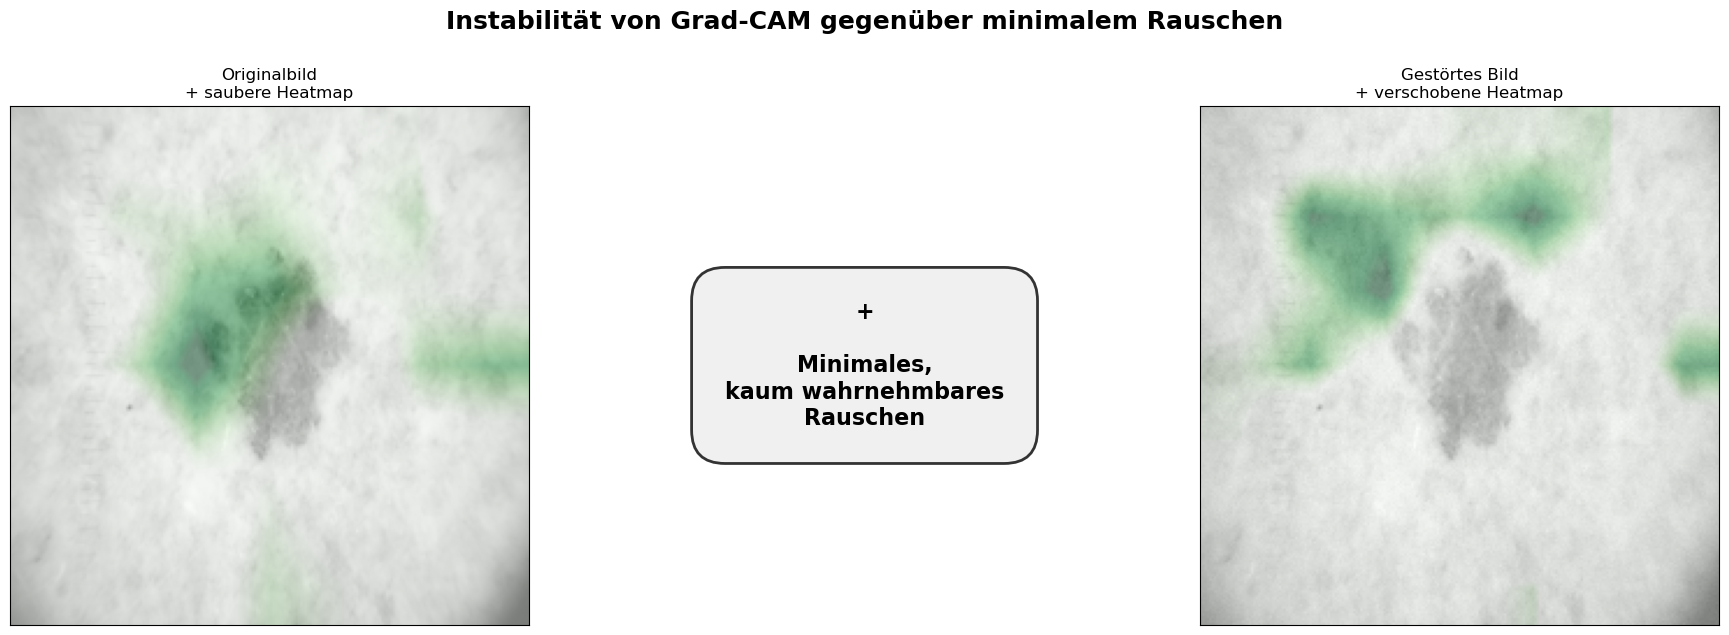

In [49]:
# Bild mit rauschen erstellen!
def plot_gradcam_instability(model, images, labels, target_layer, img_idx=0, noise_std=0.1):
    """
    Erstellt ein Vorher-Nachher-Bild, das die Instabilität von Grad-CAM bei Rauschen zeigt.
    noise_std: Standardabweichung des Rauschens (je höher, desto stärker die Störung).
    """
    # 1. Daten vorbereiten (1 Bild auswählen)
    input_img = images[img_idx: img_idx+1].to(device)
    target = labels[img_idx: img_idx+1].to(device)
    
    # 2. Minimales, kaum wahrnehmbares Rauschen hinzufügen (Gaussian Noise)
    # Entspricht methodisch Alvarez-Melis & Jaakkola (2018)
    noise = torch.randn_like(input_img) * noise_std
    noisy_img = input_img + noise
    
    # 3. Bilder für Matplotlib skalieren (Min-Max Normalisierung für den Plot)
    img_orig_plot = input_img.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
    img_orig_plot = (img_orig_plot - img_orig_plot.min()) / (img_orig_plot.max() - img_orig_plot.min() + 1e-8)
    
    img_noisy_plot = noisy_img.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
    img_noisy_plot = (img_noisy_plot - img_noisy_plot.min()) / (img_noisy_plot.max() - img_noisy_plot.min() + 1e-8)
    
    # 4. Erklärungen (Heatmaps) generieren
    model.eval()
    gradcam_func = get_gradcam_explainer(model, target_layer)
    
    # Original Heatmap
    attr_orig = gradcam_func(model, input_img, target)
    if isinstance(attr_orig, torch.Tensor): # Falls es doch mal ein Tensor ist
        attr_orig = attr_orig.squeeze(0).cpu().permute(1, 2, 0).detach().numpy()
    else: # Wenn es (wie im Fehler) bereits ein Numpy-Array ist
        attr_orig = np.squeeze(attr_orig, axis=0)
        attr_orig = np.transpose(attr_orig, (1, 2, 0))
    
    # Gestörte Heatmap (für das verrauschte Bild)
    attr_noisy = gradcam_func(model, noisy_img, target)
    if isinstance(attr_noisy, torch.Tensor):
        attr_noisy = attr_noisy.squeeze(0).cpu().permute(1, 2, 0).detach().numpy()
    else:
        attr_noisy = np.squeeze(attr_noisy, axis=0)
        attr_noisy = np.transpose(attr_noisy, (1, 2, 0))
    
    # 5. Visualisierung im gewünschten 3-Spalten-Layout
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Instabilität von Grad-CAM gegenüber minimalem Rauschen", fontsize=18, fontweight='bold', y=1.05)
    
    # Spalte 1: Originalbild + saubere Heatmap
    viz.visualize_image_attr(
        attr_orig, img_orig_plot, method="blended_heat_map", sign="positive",
        show_colorbar=False, use_pyplot=False, 
        title="Originalbild\n+ saubere Heatmap", plt_fig_axis=(fig, axs[0])
    )
    
    # Spalte 2: Das "+" Zeichen und das Kästchen (KORRIGIERT auf axs[1])
    axs[1].axis('off')
    axs[1].text(0.5, 0.5, '+\n\nMinimales,\nkaum wahrnehmbares\nRauschen', 
                fontsize=16, ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle="round,pad=1.5", fc="#f0f0f0", ec="#333333", lw=2))
    
    # Spalte 3: Gestörtes Bild + zerschossene Heatmap (KORRIGIERT auf axs[2])
    viz.visualize_image_attr(
        attr_noisy, img_noisy_plot, method="blended_heat_map", sign="positive",
        show_colorbar=False, use_pyplot=False, 
        title="Gestörtes Bild\n+ verschobene Heatmap", plt_fig_axis=(fig, axs[2])
    )
    
    plt.tight_layout()
    plt.show()

# Aufruf der Funktion (Beispiel für Ihr ResNet101):
data_iter = iter(xai_mobilenet_image_loader)
images, labels = next(data_iter)
plot_gradcam_instability(resNet101Model, images, labels, resNet101Model.layer4[-1], 0)

### Visualisierung der Erklärungstreue als Violin-Plot

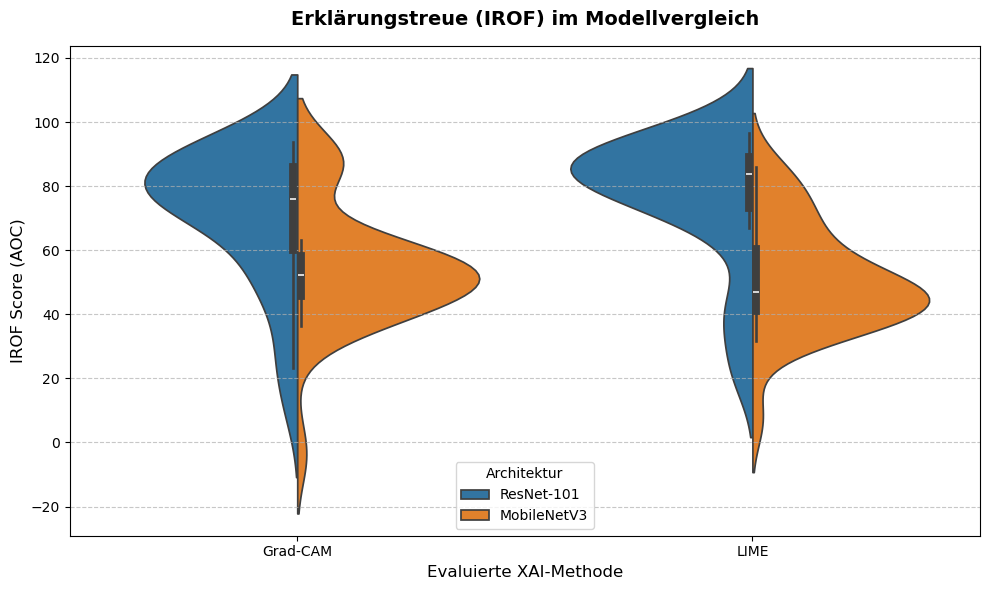

In [69]:
# --- ResNet-101 Daten ---
faith_grad_resnet = [92.4613, 43.8197, 74.9168, 51.3528, 91.1718, 75.9846, 29.1998, 90.0316, 80.5131, 73.2153, 75.5331, 85.0464, 78.9854, 46.7030, 92.5023, 71.8888, 75.1960, 58.1193, 60.7161, 83.9134, 58.4366, 76.0540, 78.2140, 78.7453, 90.3374, 71.8125, 23.2766, 88.2497, 10.4084, 84.2271, 89.2264, 93.6262]
faith_lime_resnet = [96.4620, 43.2492, 70.1298, 90.6888, 88.0375, 78.5296, 22.0342, 86.1290, 83.2196, 80.4134, 82.0970, 92.1431, 81.1343, 22.7135, 94.8421, 84.5738, 80.1461, 73.3751, 73.2712, 90.7904, 86.4116, 66.7947, 72.6379, 89.6523, 90.0999, 85.7788, 36.8838, 87.6935, 42.4586, 85.8750, 88.9620, 93.5030]

# --- MobileNetV3 Daten ---
faith_grad_mobile = [88.8333, 57.7797, 51.1560, 41.3344, 40.1525, 52.9381, 63.2086, 53.2984, 53.7326, 48.1268, 58.0388, 50.0508, 88.5189, 44.2849, 46.2662, 57.3253, 58.3802, 39.6705, 88.1187, 50.7047, 60.5030, 48.9873, 51.5827, 86.6216, 36.3420, 37.6179, 40.7641, 56.3676, 51.3279, 55.9757, -3.5310, 86.2395]
faith_lime_mobile = [75.1875, 46.5803, 57.7411, 48.5129, 37.7317, 41.7190, 78.6034, 55.5205, 59.9980, 34.9575, 43.0082, 44.7075, 42.4723, 38.8432, 35.1916, 62.0721, 52.4421, 47.0232, 69.0977, 37.9720, 71.5314, 48.1011, 43.3314, 82.9373, 46.8019, 31.6470, 65.6159, 38.5697, 50.0091, 46.3562, 7.4643, 86.0820]

# ==========================================
# 2. DATAFRAME ERSTELLEN FÜR SEABORN
# ==========================================
data = []

# ResNet-Daten anhängen
for val in faith_grad_resnet:
    data.append({'XAI-Methode': 'Grad-CAM', 'Modell': 'ResNet-101', 'IROF Score': val})
for val in faith_lime_resnet:
    data.append({'XAI-Methode': 'LIME', 'Modell': 'ResNet-101', 'IROF Score': val})

# MobileNet-Daten anhängen
for val in faith_grad_mobile:
    data.append({'XAI-Methode': 'Grad-CAM', 'Modell': 'MobileNetV3', 'IROF Score': val})
for val in faith_lime_mobile:
    data.append({'XAI-Methode': 'LIME', 'Modell': 'MobileNetV3', 'IROF Score': val})

df = pd.DataFrame(data)

# ==========================================
# 3. GRUPPIERTEN PLOT ERSTELLEN
# ==========================================
plt.figure(figsize=(10, 6))

# 'hue' und 'split' sorgen für die überlagerte, direkte Vergleichsansicht
sns.violinplot(x='XAI-Methode', y='IROF Score', hue='Modell', data=df, 
               split=True, inner='box', palette=['#1f77b4', '#ff7f0e'])

plt.title('Erklärungstreue (IROF) im Modellvergleich', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('IROF Score (AOC)', fontsize=12)
plt.xlabel('Evaluierte XAI-Methode', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legende anpassen
plt.legend(title='Architektur', loc='lower center')
plt.tight_layout()

plt.show()

### Visualisierung der Robustheit als Violin-Plot

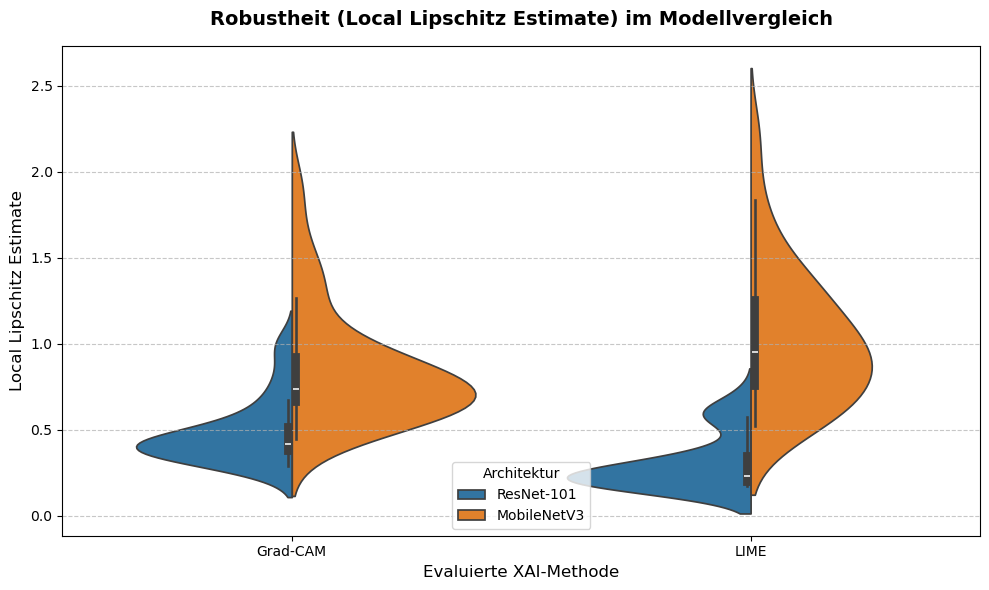

In [68]:
# --- ResNet-101 Daten ---
rob_grad_resnet = [0.3938, 0.3807, 1.0087, 0.4216, 0.3379, 0.9721, 0.4353, 0.4098, 0.2915, 0.4038, 0.4298, 0.2980, 0.4962, 0.6703, 0.4088, 0.4281, 0.5416, 0.3765, 0.4685, 0.3285, 0.4868, 0.4161, 0.3679, 0.3404, 0.3265, 0.6157, 0.6097, 0.7509, 0.8328, 0.3424, 0.4068, 0.5046]
rob_lime_resnet = [0.5796, 0.2121, 0.3770, 0.1754, 0.1700, 0.6993, 0.2831, 0.1809, 0.3383, 0.2182, 0.2903, 0.3154, 0.1808, 0.2665, 0.3781, 0.2197, 0.1987, 0.2306, 0.2757, 0.1972, 0.2692, 0.1893, 0.1748, 0.1827, 0.2242, 0.2350, 0.5864, 0.5737, 0.5936, 0.2097, 0.1773, 0.5990]

# --- MobileNetV3 Daten ---
rob_grad_mobile = [0.8903, 0.8433, 0.6700, 0.9808, 0.6653, 1.0210, 1.2674, 0.6240, 1.3576, 0.5991, 1.0480, 0.7141, 0.5874, 0.5390, 0.6449, 0.6734, 0.7630, 0.6867, 0.8297, 0.7854, 1.4032, 0.6685, 0.9022, 1.6025, 0.8016, 0.4461, 0.8231, 0.5450, 0.6705, 0.7096, 0.5578, 1.9018]
rob_lime_mobile = [1.3891, 0.7398, 1.3414, 0.9119, 1.0601, 0.8069, 0.8961, 1.5162, 0.9040, 0.6081, 0.8062, 0.7590, 1.2249, 0.5351, 1.0121, 1.2427, 0.6190, 0.5852, 1.3218, 0.6100, 0.9927, 1.0700, 0.5186, 1.8363, 0.8020, 1.6199, 1.0374, 2.2068, 0.5837, 0.8772, 1.0502, 1.2806]

# ==========================================
# 2. DATAFRAME ERSTELLEN FÜR SEABORN
# ==========================================
data = []

# ResNet-Daten anhängen
for val in rob_grad_resnet:
    data.append({'XAI-Methode': 'Grad-CAM', 'Modell': 'ResNet-101', 'Local Lipschitz Estimate': val})
for val in rob_lime_resnet:
    data.append({'XAI-Methode': 'LIME', 'Modell': 'ResNet-101', 'Local Lipschitz Estimate': val})

# MobileNet-Daten anhängen
for val in rob_grad_mobile:
    data.append({'XAI-Methode': 'Grad-CAM', 'Modell': 'MobileNetV3', 'Local Lipschitz Estimate': val})
for val in rob_lime_mobile:
    data.append({'XAI-Methode': 'LIME', 'Modell': 'MobileNetV3', 'Local Lipschitz Estimate': val})

df = pd.DataFrame(data)

# ==========================================
# 3. GRUPPIERTEN PLOT ERSTELLEN
# ==========================================
plt.figure(figsize=(10, 6))

# 'hue' und 'split' sorgen für die überlagerte, direkte Vergleichsansicht
sns.violinplot(x='XAI-Methode', y='Local Lipschitz Estimate', hue='Modell', data=df, 
               split=True, inner='box', palette=['#1f77b4', '#ff7f0e'])

plt.title('Robustheit (Local Lipschitz Estimate) im Modellvergleich', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Local Lipschitz Estimate', fontsize=12)
plt.xlabel('Evaluierte XAI-Methode', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legende anpassen
plt.legend(title='Architektur', loc='lower center')
plt.tight_layout()

plt.show()